In [8]:
# Install the necessary libraries
!pip install pandas scikit-learn matplotlib seaborn

#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [38]:
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive
!apt-get -qq install -y graphviz && pip install pydot
import pydot
!pip install cartopy
import cartopy

Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 126281 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.5_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.8 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31629 sha256=496b3db738adfd9064f195c9b66e8443ef3ce0ded20cbe64e681818efe14ec60
  Stored in directory: /root/.cache/pip/wheels/32/98/bd/4893d6923dd027f455b250367d402bfd69a6f4416581df46db
Successfully built libarchive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 103.3 MB/s eta 0:00:00


Load The Dataset

In [3]:
df= pd.read_csv('/content/creditcard[1].csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Data Exploration

In [5]:
# Check the shape of the dataset
print(f"Shape of the dataset:{df.shape}")

#Check datatype and null values
print(df.info())

#Display basic statistics
df.describe()

Shape of the dataset:(188261, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188261 entries, 0 to 188260
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    188261 non-null  float64
 1   V1      188261 non-null  float64
 2   V2      188261 non-null  float64
 3   V3      188261 non-null  float64
 4   V4      188261 non-null  float64
 5   V5      188261 non-null  float64
 6   V6      188261 non-null  float64
 7   V7      188261 non-null  float64
 8   V8      188261 non-null  float64
 9   V9      188261 non-null  float64
 10  V10     188261 non-null  float64
 11  V11     188261 non-null  float64
 12  V12     188261 non-null  float64
 13  V13     188260 non-null  float64
 14  V14     188260 non-null  float64
 15  V15     188260 non-null  float64
 16  V16     188260 non-null  float64
 17  V17     188260 non-null  float64
 18  V18     188260 non-null  float64
 19  V19     188260 non-null  float64
 20  V20     188260

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,188261.000000,...,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000,188260.000000
mean,66911.456133,-0.126822,0.014291,0.382492,0.088906,-0.135514,0.051997,-0.062135,0.022762,0.012470,...,-0.018643,-0.060736,-0.018176,0.006076,0.072208,0.008481,0.001743,0.002159,89.001873,0.001955
std,32193.455193,1.880580,1.617636,1.428443,1.390410,1.356318,1.306515,1.212057,1.215524,1.141162,...,0.740575,0.683142,0.602327,0.602126,0.481530,0.489465,0.392296,0.309245,247.536677,0.044169
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,43063.000000,-0.969960,-0.568821,-0.232844,-0.777499,-0.800564,-0.702594,-0.580756,-0.174494,-0.661910,...,-0.228172,-0.540946,-0.169179,-0.338314,-0.225180,-0.331167,-0.066674,-0.037728,5.947500,0.000000
50%,64747.000000,-0.121054,0.088501,0.542372,0.091115,-0.190869,-0.212486,-0.018999,0.047961,-0.075250,...,-0.047004,-0.046416,-0.031424,0.055086,0.116006,-0.060301,0.006936,0.019435,22.740000,0.000000
75%,84168.000000,1.202527,0.788329,1.252559,0.905617,0.432033,0.446707,0.485381,0.342508,0.630737,...,0.143128,0.401626,0.109334,0.419810,0.389857,0.265841,0.089280,0.078149,79.000000,0.000000
max,127894.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


Visualize Class Distribution

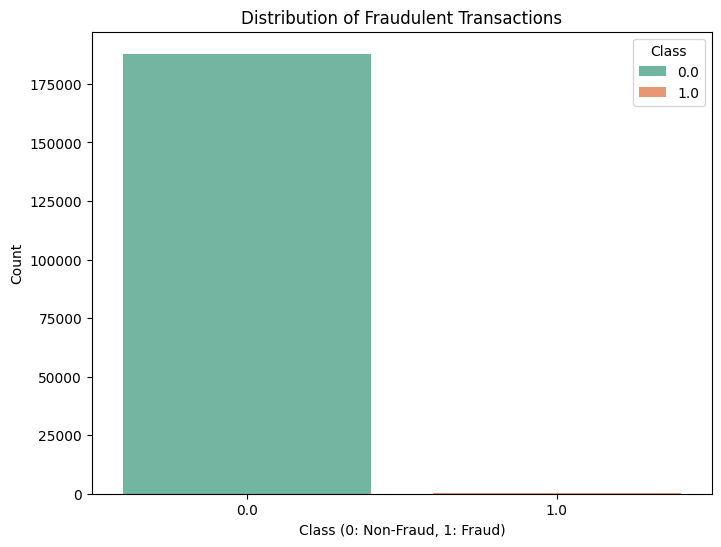

In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, hue='Class', palette='Set2')
plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.show()

Feature Engineering

In [15]:
# Separate features and target variable
X= df.drop('Class', axis=1)
y= df['Class']

# Standardize the features
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Logistic Regression

In [19]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Train Logistic Regression model
log_model=LogisticRegression()
log_model.fit(X_train, y_train)

#Make predictions
y_pred_log=log_model.predict(X_test)

#Evaluate the model
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train Decision Tree model
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

#Make predictions
y_pred_dt=dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Random Forest Classifier

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



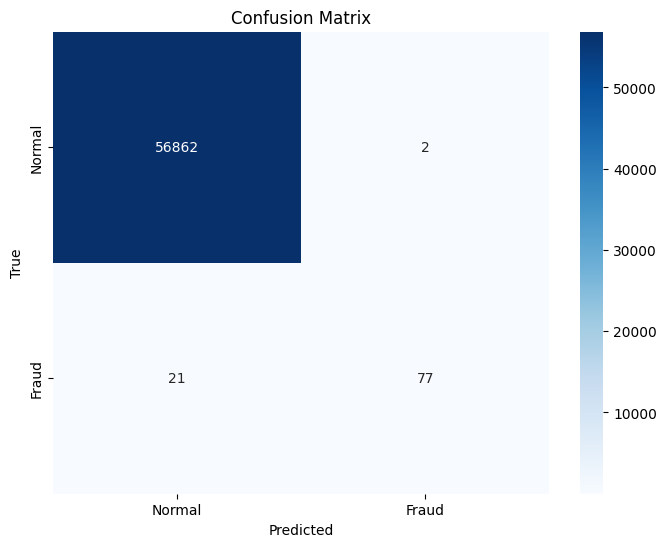

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Step 2: Load the dataset
df=pd.read_csv(r'/content/creditcard[1].csv')

#Step 3: Preprocessing (assuming 'Class' is the target variable)
X=df.drop('Class', axis=1) # Features
y=df['Class'] # Target variable

#Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#Step 5: Train the Random Forest model
rf_model=RandomForestClassifier()
rf_model.fit(X_train, y_train)

#Step 6: Make predictions
y_pred_rf=rf_model.predict(X_test)

#Step 7: Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

#Step 8: Confusion Matrix
cm=confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Neural Network Classifier

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.59      0.70      0.64        98

    accuracy                           1.00     56962
   macro avg       0.80      0.85      0.82     56962
weighted avg       1.00      1.00      1.00     56962



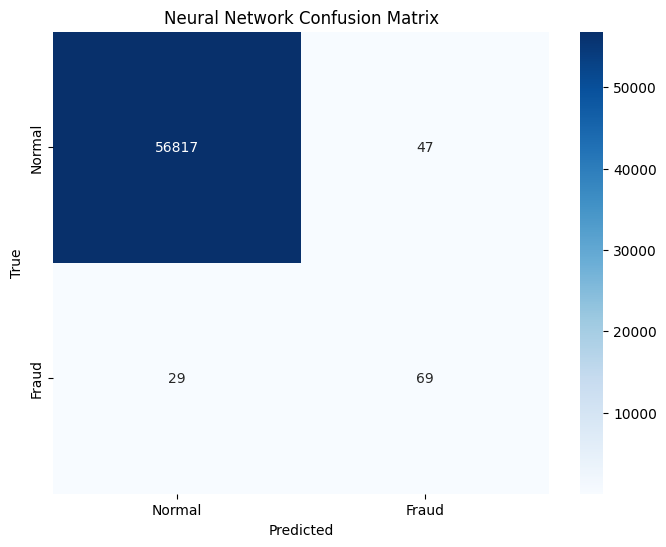

In [4]:
#Step 1: Install necessary libraries if not already installed
#!pip install pandas numpy scikit-Learn seaborn matplotlib

#Step 2: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier #Importing MLPClassifier

#Step 3: Load the dataset

df=pd.read_csv(r'/content/creditcard[1].csv')

#Step 4: Preprocessing (assuming 'Class' is the target variable)
X=df.drop('Class', axis=1)       # Features
y=df['Class']   #Targetvartable

#Step 5: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#Step 6: Train the Neural Network model
nn_model=MLPClassifier(max_iter=300)
nn_model.fit(X_train, y_train)

#Step 7: Make predictions
y_pred_nn=nn_model.predict(X_test)

#Step 8: Evaluate the model

print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))

#Step 9: Optional Confusion Matrix
cm_nn=confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Visualise Confusion Matrices

In [8]:
#Features (X) and Target (y)
X=df.drop('Class', axis=1) #Drop the target column from features
y=df['Class'] # The target column (fraud or not)

from sklearn.model_selection import train_test_split

#Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 1: Load the required Librartes
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

#Step 2: Load the dataset
df=pd.read_csv(r'/content/creditcard[1].csv')

#Step 3: Prepare features (X) and target (y)
X=df.drop('Class', axis=1) # Features (all columns except 'Class')
y=df['Class'] # Target (fraud or not)

#Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#Step 5: Standardize the feature data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#Step 6: Train Logistic Regression
log_model=LogisticRegression(max_iter=300)
log_model.fit(X_train_scaled, y_train)

#Step 7: Train Decision Tree
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

#Step 8: Train Random Forest
rf_model=RandomForestClassifier()
rf_model.fit(X_train, y_train)

#Step 9: Train Neural Network
nn_model=MLPClassifier(max_iter=308)
nn_model.fit(X_train_scaled, y_train)

#Step 10: Make predictions
#Logistic Regression
y_pred_log=log_model.predict(X_test_scaled)

Feature Importance Plot (for Random Forest)

/tmp/ipython-input-10-3366087372.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


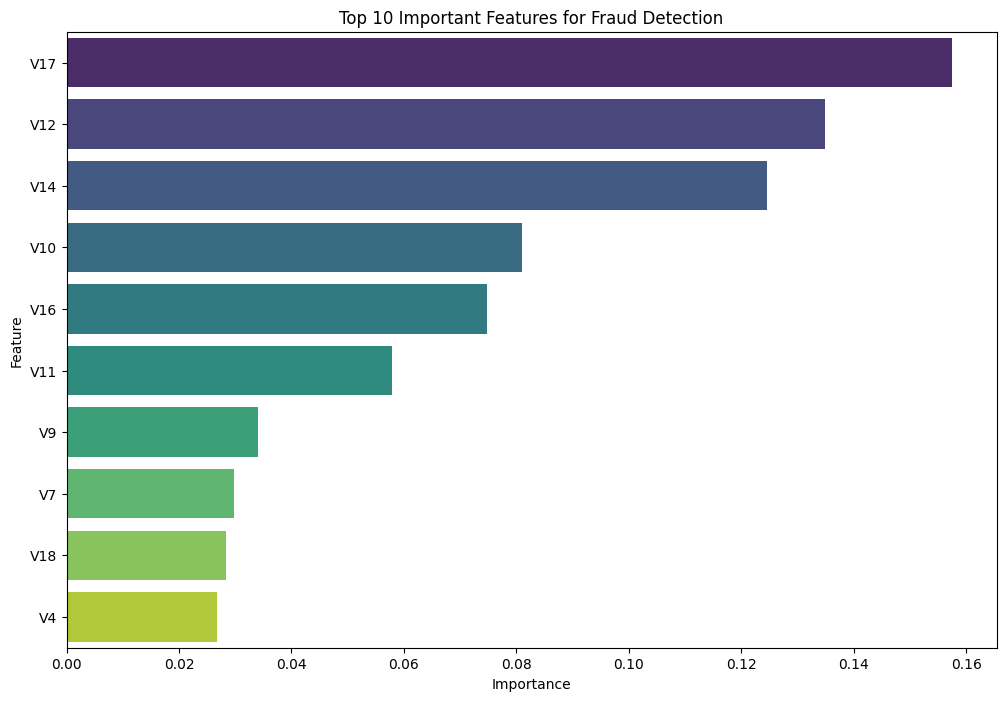

In [10]:
#Step 1: Import necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier # Corrected import

#Step 2: Load the dataset
df = pd.read_csv("/content/creditcard[1].csv") # Load the dataset

#Step 3: Prepare features (X) and target (y)
X = df.drop('Class', axis=1) # Features (all columns except 'class') - Corrected assignment and axis
y = df['Class'] # Target (fraud or not) - Corrected assignment

#Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Corrected test_size

#Step 5: Standardize the feature data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Step 6: Train Random Forest model
rf_model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
rf_model.fit(X_train, y_train)

#Step 7: Make predictions with Random Forest
y_pred_rf = rf_model.predict(X_test)

#Step 8: Get feature importances from Random Forest model
feature_importances = rf_model.feature_importances_ # Corrected attribute access

#Step 9: Create a DataFrame for visualization
features = X.columns             #Use feature names from X, which excludes 'Class'
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

#Step 10: Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Important Features for Fraud Detection')
plt.show()

ROC Curve

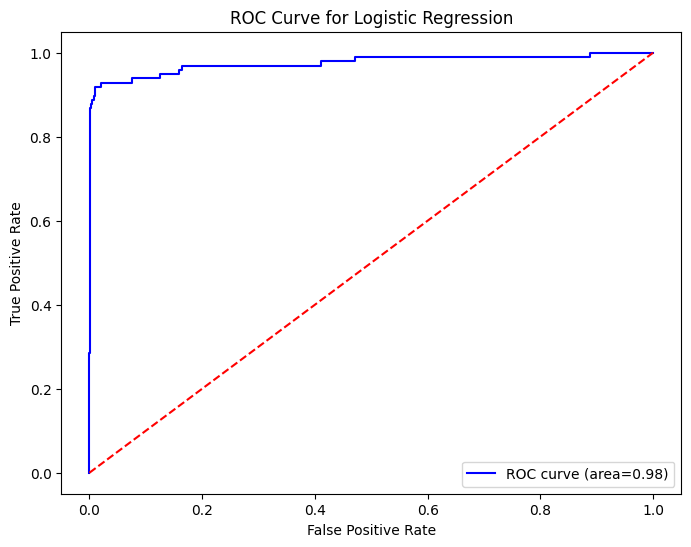

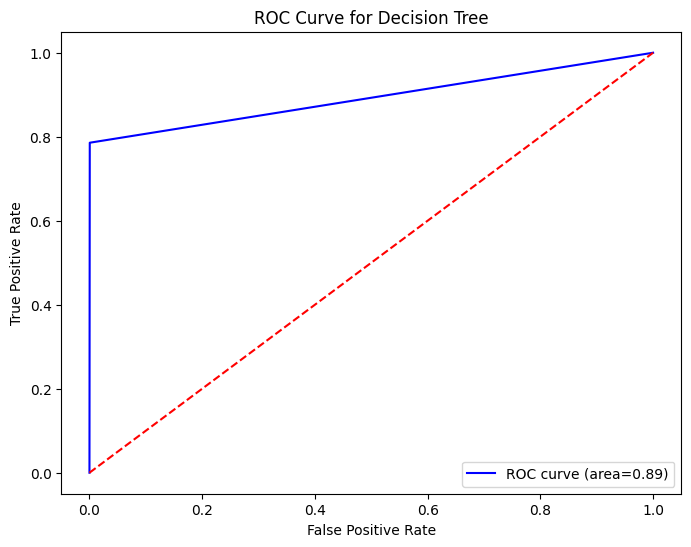

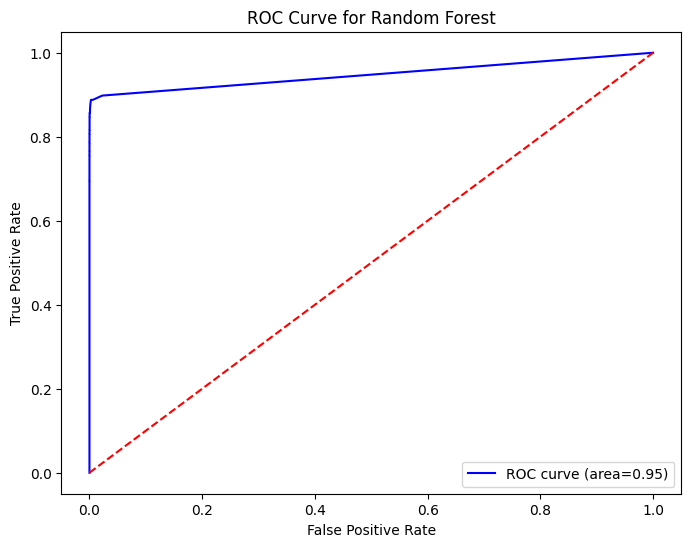

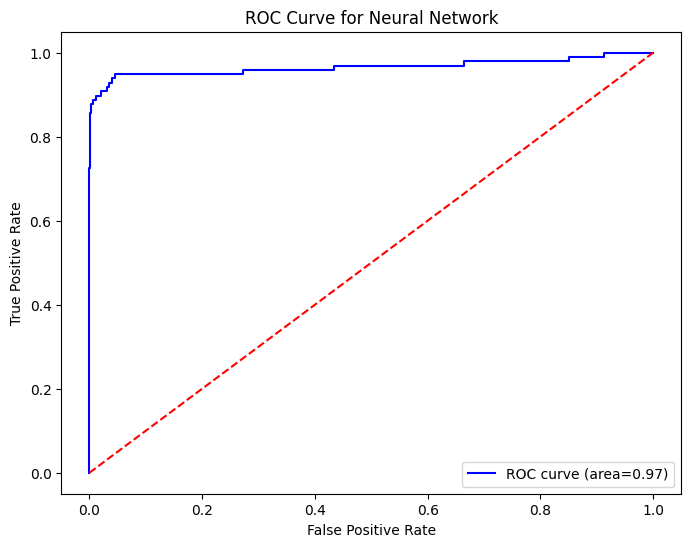

In [12]:
from sklearn.metrics import roc_curve, auc

#Function to plot ROC curve
def plot_roc_curve(y_true, y_scores, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc=auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label='ROC curve (area=%0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.title(f'ROC Curve for {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

#Plot ROC curve for each model
plot_roc_curve(y_test, log_model.predict_proba(X_test_scaled)[:, 1], "Logistic Regression")
plot_roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1], "Decision Tree")
plot_roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1], "Random Forest")
plot_roc_curve(y_test, nn_model.predict_proba(X_test_scaled)[:, 1], "Neural Network") # Corrected index for nn_model

Boxplots to identify outliers

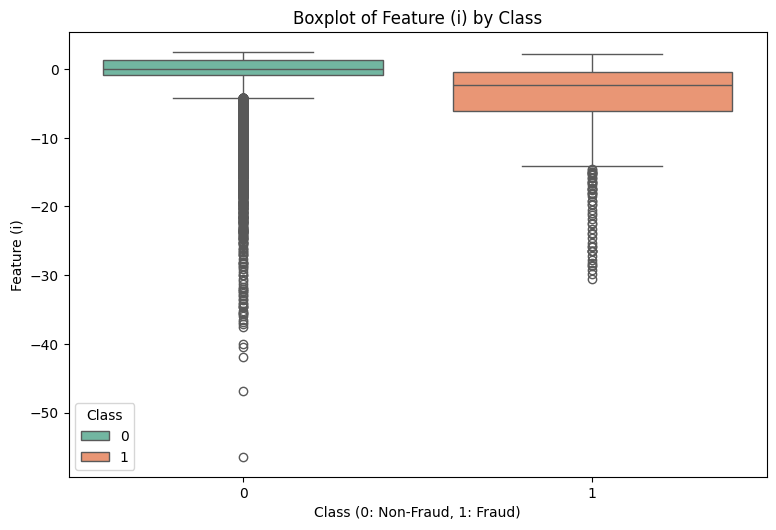

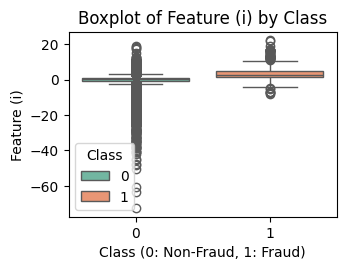

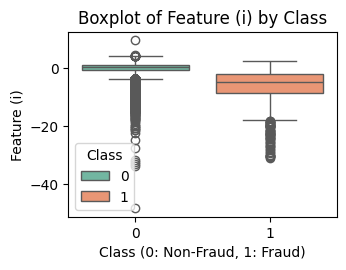

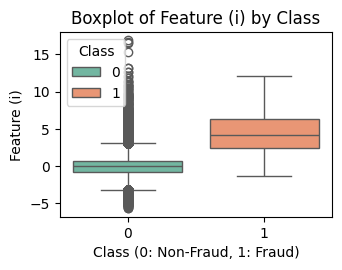

In [14]:
# Create boxplots for the first few features
plt.figure(figsize=(15, 10))

for i in range(1, 5): #Adjust the range to visualize more features
 plt.subplot(2, 2, 1)
 sns.boxplot(x='Class', y=df.columns[i], data=df, hue='Class', palette='Set2')
 plt.title(f'Boxplot of Feature (i) by Class')
 plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
 plt.ylabel(f'Feature (i)')
 plt.tight_layout()
 plt.show()

Pair Plot to visualise Feature Relationships

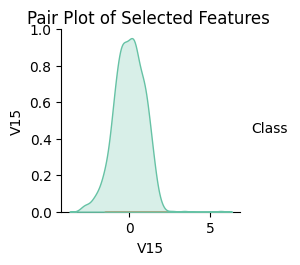

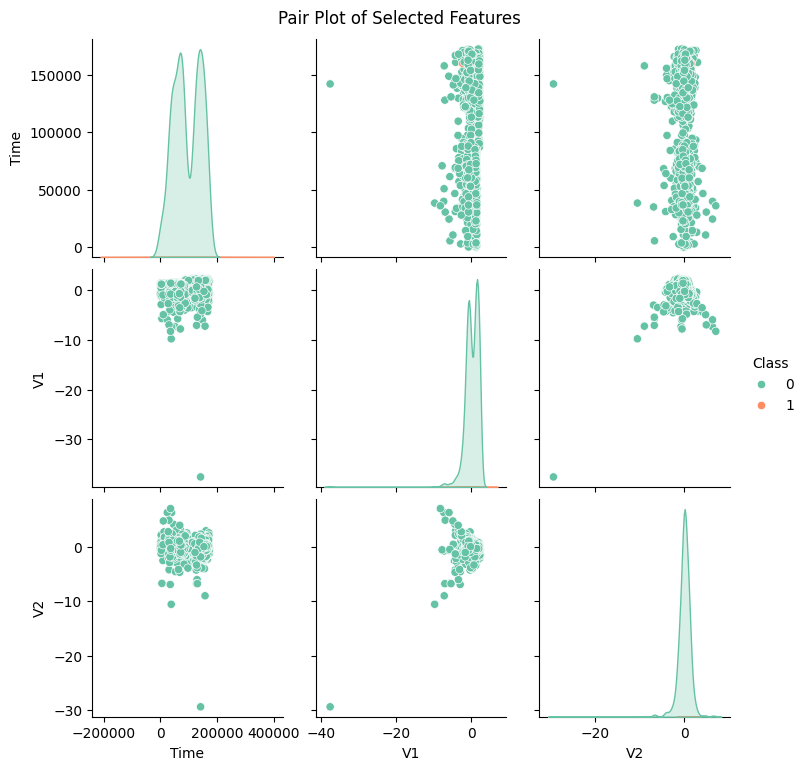

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Load your dataset
df=pd.read_csv('/content/creditcard[1].csv')

#Sample 1000 rows from the dataset to reduce computation time
data_sampled=df.sample(1000)

#Create pair plot on the sampled data
subset_features=data_sampled.columns[[15]] # Adjust the features as needed - corrected indexing
sns.pairplot(data_sampled[subset_features].assign(Class=data_sampled['Class']), hue='Class', palette='Set2') # Using data_sampled
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()

#Use only 3 features for faster execution
subset_features=data_sampled.columns[:3] # Using data_sampled and corrected indexing for multiple columns
sns.pairplot(data_sampled[subset_features].assign(Class=data_sampled['Class']), hue='Class', palette='Set2') # Using data_sampled
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()

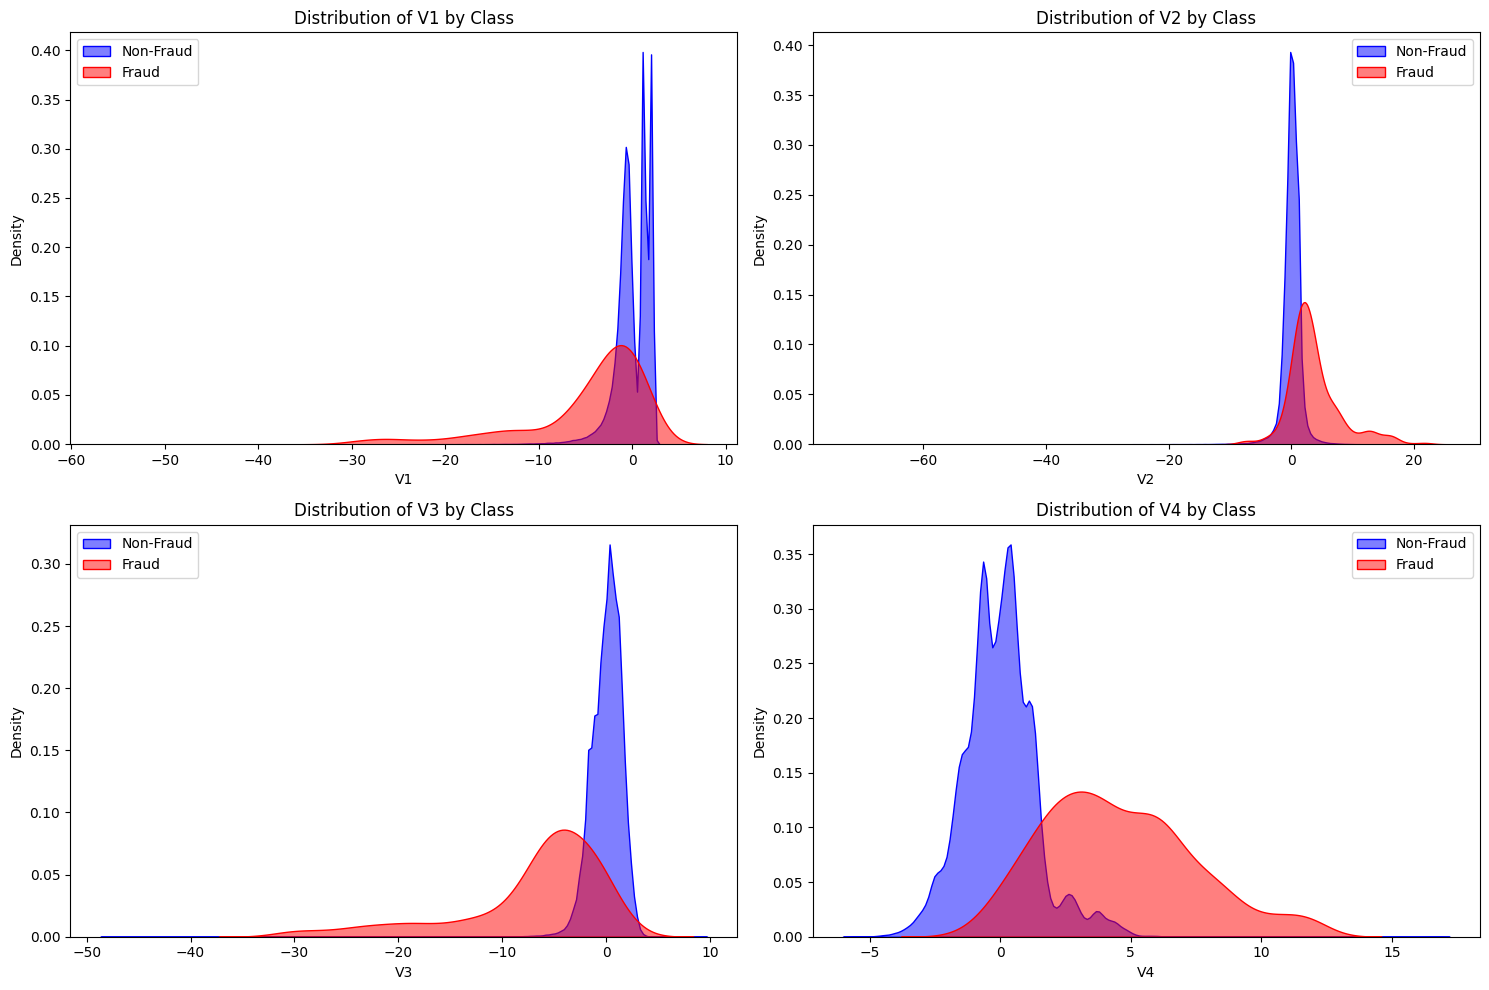

In [24]:
#Distribution plots for selected features
plt.figure(figsize=(15, 10))

for i in range(1, 5): # Adjust the range to visualize more features
    plt.subplot(2, 2, i)
    sns.kdeplot(df[df['Class']==0][df.columns[i]], label='Non-Fraud', fill=True, color='blue', alpha=0.5) # Corrected alpha value
    sns.kdeplot(df[df['Class']==1][df.columns[i]], label='Fraud', fill=True, color='red', alpha=0.5) # Corrected alpha value
    plt.title(f'Distribution of {df.columns[i]} by Class') # Dynamically update title
    plt.xlabel(f'{df.columns[i]}') # Use feature name in xlabel
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

Violin Plots for feature Distribution

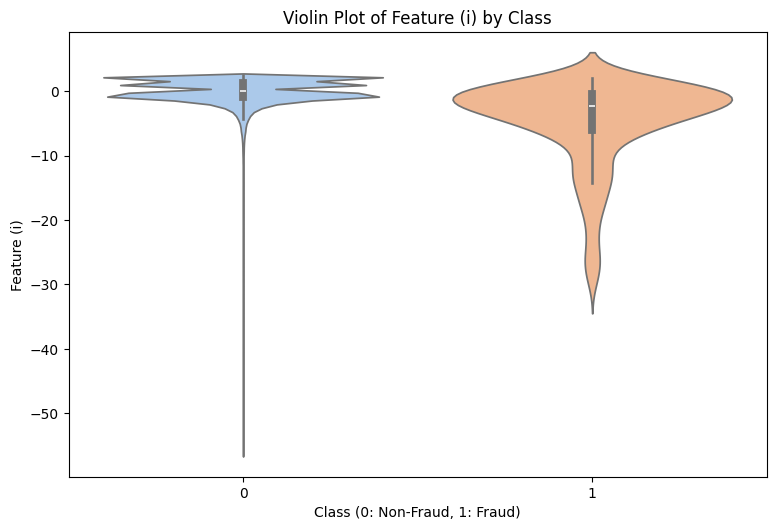

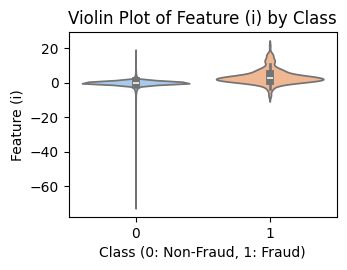

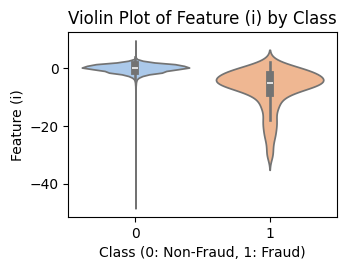

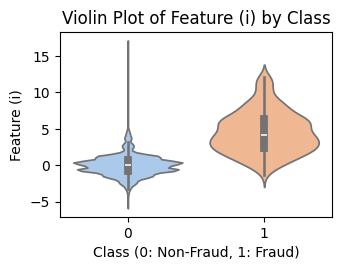

In [28]:
#Create violin plots for the first few features
plt.figure(figsize=(15, 10))

for i in range(1, 5): # Adjust the range to visualize more features
   plt.subplot(2, 2, 1)
   sns.violinplot(x='Class', y=df.columns[i], data=df, hue='Class', palette='pastel', legend=False)
   plt.title(f'Violin Plot of Feature (i) by Class')
   plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
   plt.ylabel(f'Feature (i)')
   plt.tight_layout()
   plt.show()

Cummulative Gains and Lifts Charts

In [30]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [31]:
#Assuming data is your DataFrame and 'Class' is your target variable column
X=df.drop(columns=['Class']) # Replace 'target' with 'Class'
y=df['Class'] # Use the correct target variable name

#Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
!pip install scikitplot

import pandas as pd
import scikitplot as skplt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

#Check the columns of the DataFrame
print(df.columns)

# Inspect the columns
#Assume the target variable is identified correctly as 'Class'
X=df.drop(columns=['Class']) # Replace 'Class' with your actual target variable name
y=df['Class']

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#Scale the data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#Initialize and train models with adjusted parameters

log_model=LogisticRegression(max_iter=1000) #Increased max_iter
dt_model=DecisionTreeClassifier()
rf_model=RandomForestClassifier()
nn_model=MLPClassifier(max_iter=500)
log_model.fit(X_train_scaled, y_train)

#Fit on scaled data
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
nn_model.fit(X_train_scaled, y_train) # Fit NN on scaled data

#Now, you can plot cumulative gains
skplt.metrics.plot_cumulative_gain(y_test, log_model.predict_proba(X_test_scaled)[:, 1], "Logistic Regression")
skplt.metrics.plot_cumulative_gain(y_test, dt_model.predict_proba(X_test)[:, 1], "Decision Tree")
skplt.metrics.plot_cumulative_gain(y_test, rf_model.predict_proba(X_test)[:, 1], "Random Forest")
skplt.metrics.plot_cumulative_gain(y_test, nn_model.predict_proba(X_test_scaled)[:, 1], "Neural Network") # Predict proba on scaled data

ERROR: Could not find a version that satisfies the requirement scikitplot (from versions: none)
ERROR: No matching distribution found for scikitplot


ImportError: cannot import name 'interp' from 'scipy' (/usr/local/lib/python3.11/dist-packages/scipy/__init__.py)

Lift Charts

In [43]:
#Inspect the columns of the Dataframe
print(df.columns) #Check column names to identify the target column

#Define features and target variable
X=df.drop(columns=['V2']) # Replace 'target' with your actual target variable name
y=df['V2']

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#Check the target variable
print(y_train.unique()) # Display unique values
print(y_train.dtype) #Display the data type

#Convert to binary if necessary (for binary classification)
if y_train.dtype in [np.float64, np.float32]: # Continuous
   y_train = (y_train > 0.5).astype(int) # Convert to binary

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
[-0.38078271 -0.62694277  0.82056565 ...  0.14402297  0.99294612
 -0.7848505 ]
float64


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Scale the features
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#Initialize and fit the model with increased max_iter
log_model=LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

Piano Graph

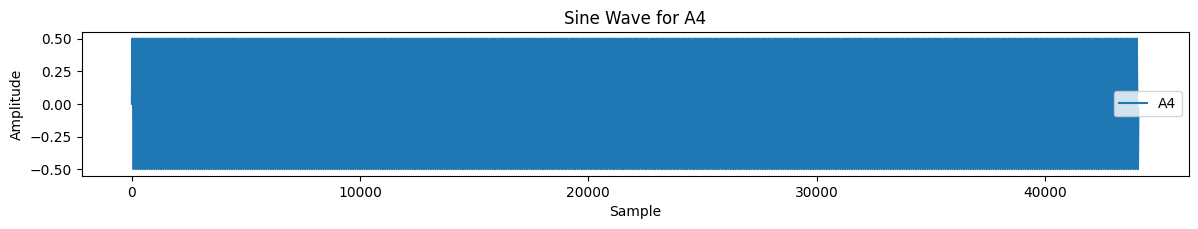

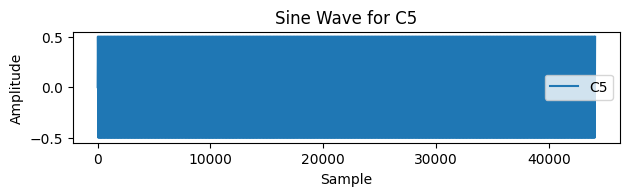

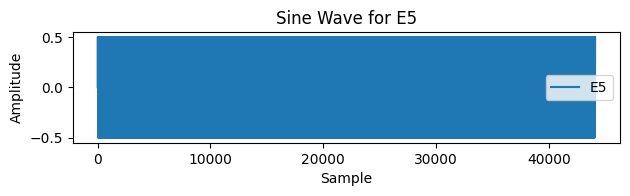

In [48]:
#Function to generate a sine wave for a given frequency
def sine_wave (frequency, duration=1.0, sample_rate=44100):
    t= np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    return 0.5*np.sin(2*np.pi*frequency * t)

# Frequencies for some piano notes (A4, C5, E5)
frequencies=[440, 523.25, 659.25] # A4, C5, E5
note_labels=['A4', 'C5', 'E5']
waves=[sine_wave(f) for f in frequencies]

#Plot the sine waves
plt.figure(figsize=(12, 6))
for i, wave in enumerate (waves):
   plt.subplot(3, 1, i+1)
   plt.plot(wave, label=note_labels[i])
   plt.title(f'Sine Wave for {note_labels[i]}') # Corrected title formatting
   plt.xlabel('Sample')
   plt.ylabel('Amplitude')
   plt.legend()

   plt.tight_layout()
   plt.show()



*Table Graph*
Displays data in rows and columns, often used as the base for plotting graphs.





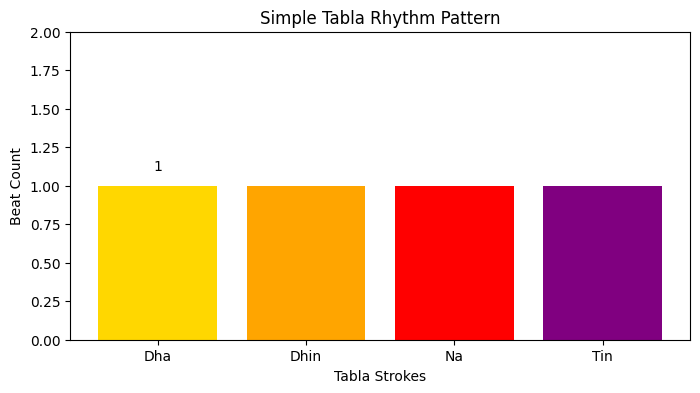

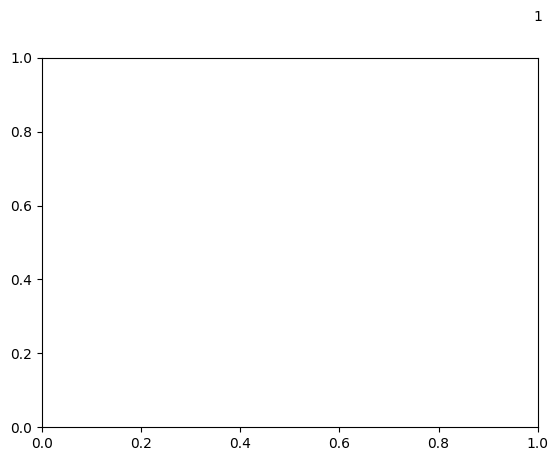

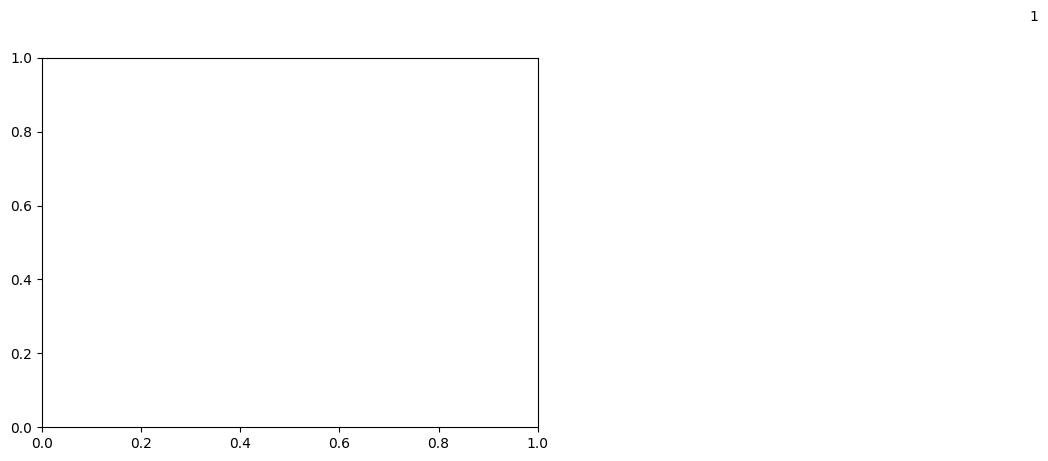

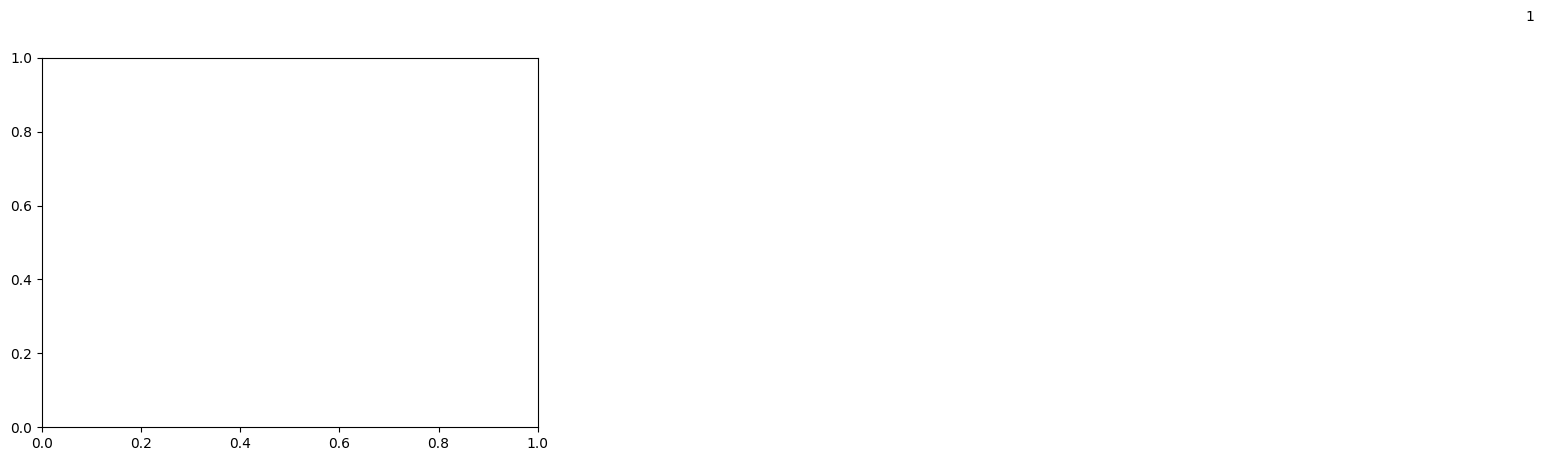

In [50]:
# Sample tabla rhythm pattern (simplified representation)
tabla_strokes = ['Dha', 'Dhin', 'Na', 'Tin']
beat_counts=[1, 1, 1, 1] #Equal weight for each stroke for this example

#Plot the tabla rhythm
plt.figure(figsize=(8, 4))
plt.bar(tabla_strokes, beat_counts, color=['gold', 'orange', 'red', 'purple'])
plt.title('Simple Tabla Rhythm Pattern')
plt.xlabel('Tabla Strokes')
plt.ylabel('Beat Count')
plt.ylim(0, max(beat_counts) + 1)

#Add annotations

for i, count in enumerate (beat_counts):
   plt.text(i, count + 0.1, str(count), ha='center')

   plt.show()

Beating Drum Graphs

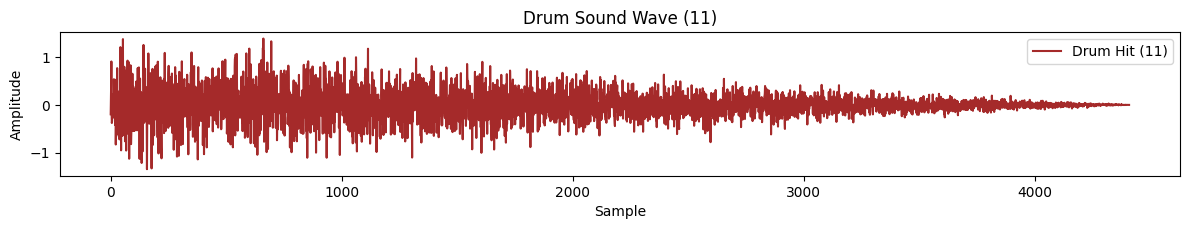

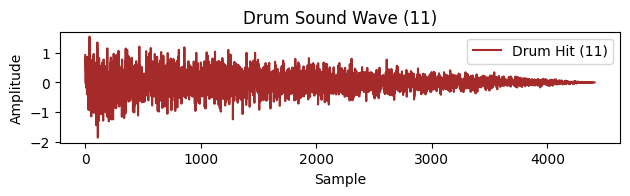

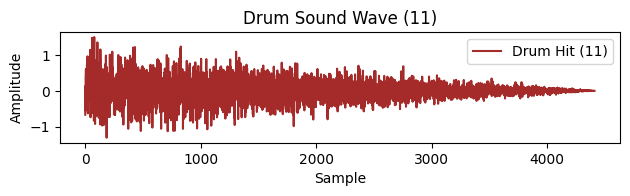

In [52]:
#Function to generate a drum sound (short burst of noise)
def drum_sound(duration=0.1, sample_rate=44100):
    t=np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    noise=np.random.normal(0, 1, t.shape)
    return 0.5*noise*(1-t/ duration) # Decaying amplitude

#Generate multiple drum hits
drum_waves=[drum_sound() for _ in range(3)]

# Three drum hits
#Plot the drum sounds
plt.figure(figsize=(12, 6))

for i, wave in enumerate (drum_waves):
  plt.subplot(3, 1, i+1)
  plt.plot(wave, label=f'Drum Hit (11)', color='brown')
  plt.title(f'Drum Sound Wave (11)')
  plt.xlabel('Sample')
  plt.ylabel('Amplitude')
  plt.legend()
  plt.tight_layout()
  plt.show()

**Flute Graph**
It gets its name because the bars resemble the vertical pipes of a flute (long and thin).



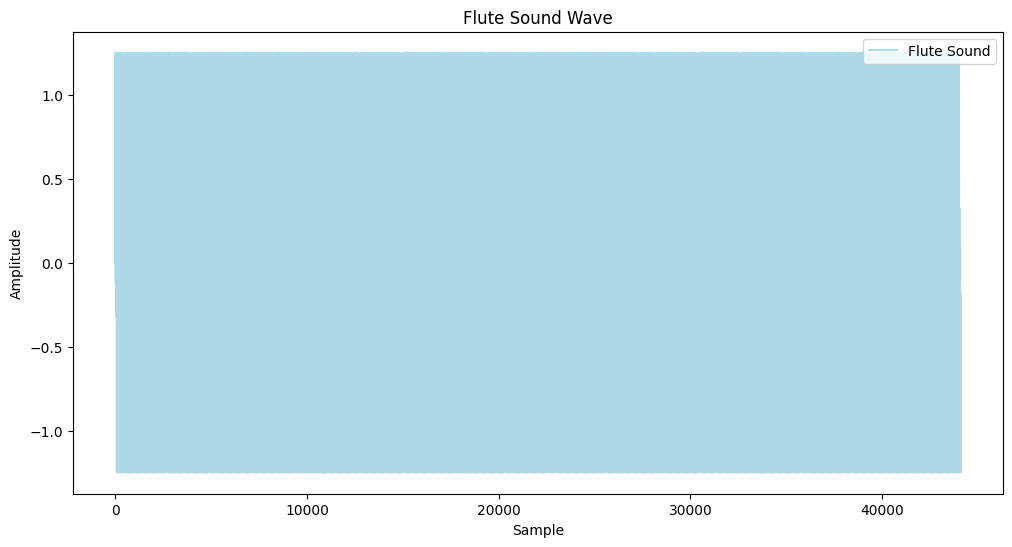

In [3]:
# Function to generate o flute sound by summing sine waves

def flute_sound(duration=1.0, sample_rate=44100):
    frequencies = [440, 880, 1320] # Fundamental and two harmonics (A4, A5, A6)
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    wave = sum(0.5 * np.sin(2 * np.pi * f * t) for f in frequencies)
    return wave

#Generate flute sound
flute_wave = flute_sound()

#Plot the flute sound
plt.figure(figsize=(12, 6))
plt.plot(flute_wave, label='Flute Sound', color='lightblue')
plt.title('Flute Sound Wave')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

**Mouth Organ Graph**
"Mouth Organ Graph" is an informal or non-technical term, often used in school-level learning or presentations to describe a graph that visually resembles a mouth organ (harmonica)

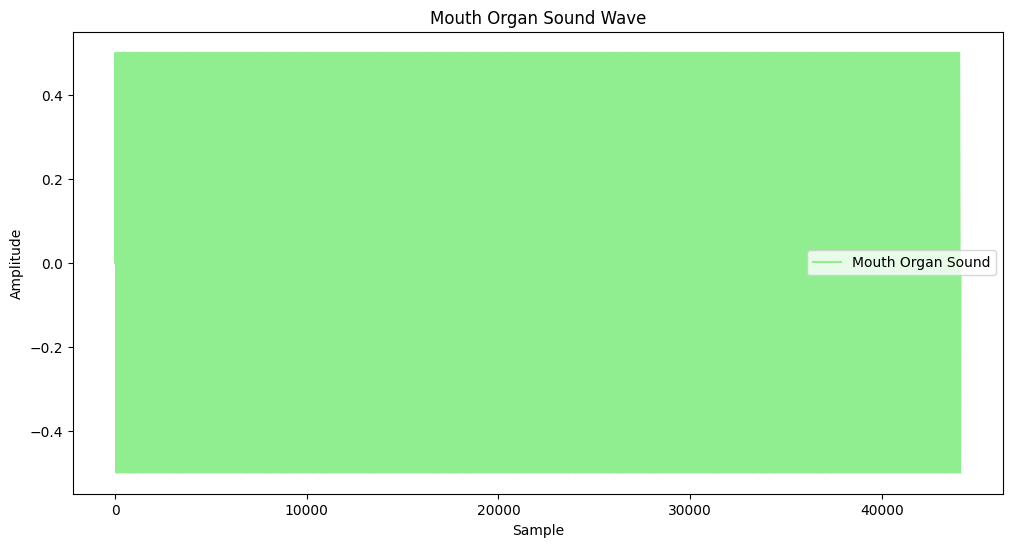

In [7]:
#Function to generate a mouth organ sound with slight modulation
import numpy as np # Import numpy
import matplotlib.pyplot as plt # Import matplotlib


def mouth_organ_sound(duration=1.0, sample_rate=44100):
   fundamental = 440 # A4
   t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
   modulation = 0.1*np.sin(2*np.pi*5*t) # Tremolo effect
   wave=0.5*np.sin(2*np.pi*fundamental * t + modulation) #Add modulation
   return wave

#Generate mouth organ sound
mouth_organ_wave=mouth_organ_sound()

#Plot the mouth organ sound
plt.figure(figsize=(12, 6))
plt.plot(mouth_organ_wave, label='Mouth Organ Sound', color='lightgreen')
plt.title('Mouth Organ Sound Wave')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Transaction Amount Distribution

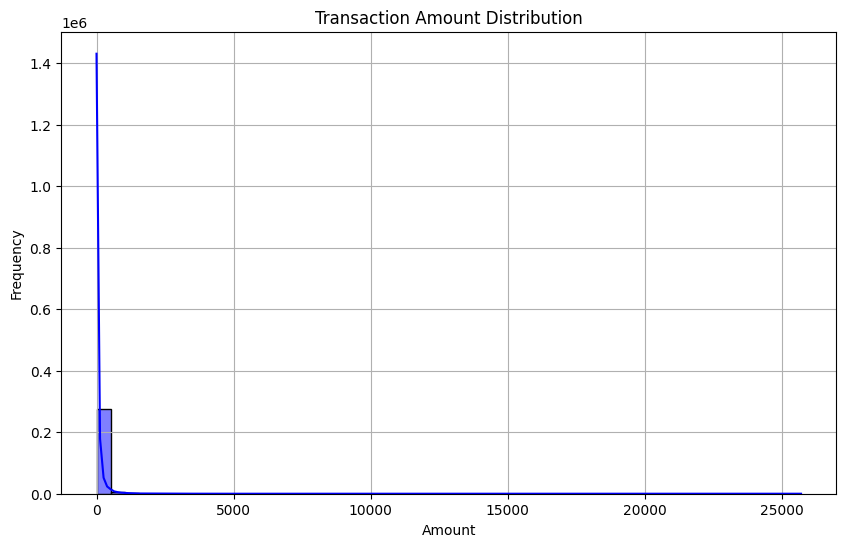

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
df= pd.read_csv('/creditcard[1].csv')

#Assuming df is defined and contains the 'Amount column
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True, color='blue')
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid()
plt.show()

**Time Series Analysis of Transaction**
Time Series Analysis (TSA) is a statistical technique used to analyze data points collected or recorded at specific time intervals, usually to understand trends, patterns, and make predictions

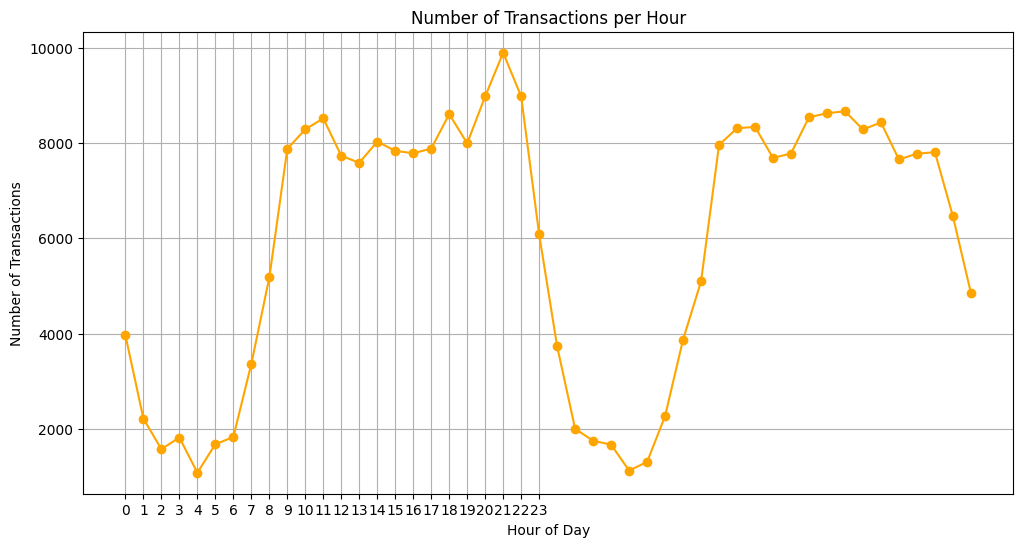

In [12]:
#Convert the 'Time' column to hours and count transactions per hour
df['Hour']=(df['Time'] / 3600).astype(int)
transactions_per_hour = df ['Hour'].value_counts().sort_index()

#Plotting transactions over time
plt.figure(figsize=(12, 6))
plt.plot(transactions_per_hour.index, transactions_per_hour.values, marker='o', color='orange')
plt.title('Number of Transactions per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

Feature Correlation Heatmap

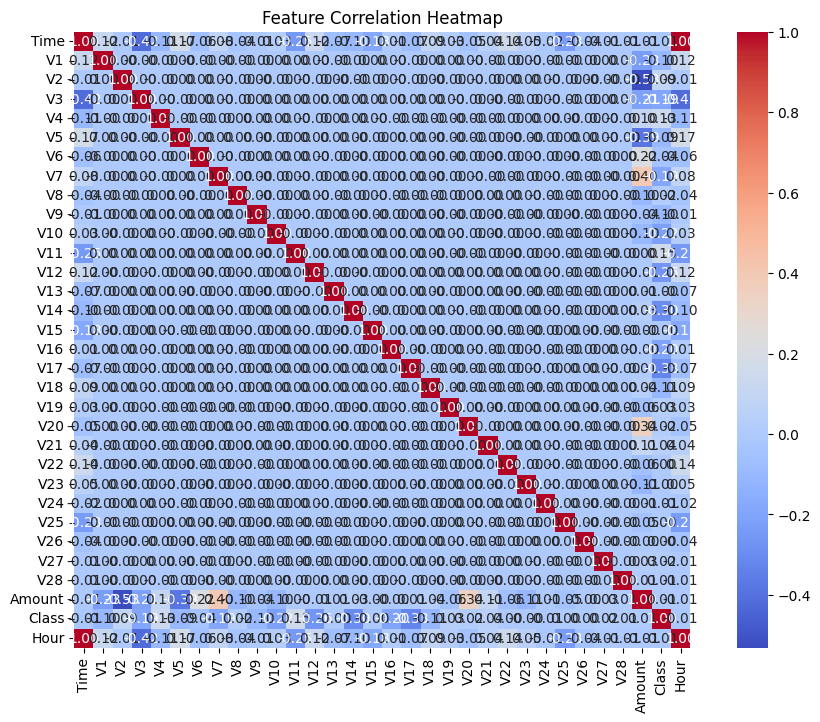

In [13]:
#Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

Anomaly Detection Visualization

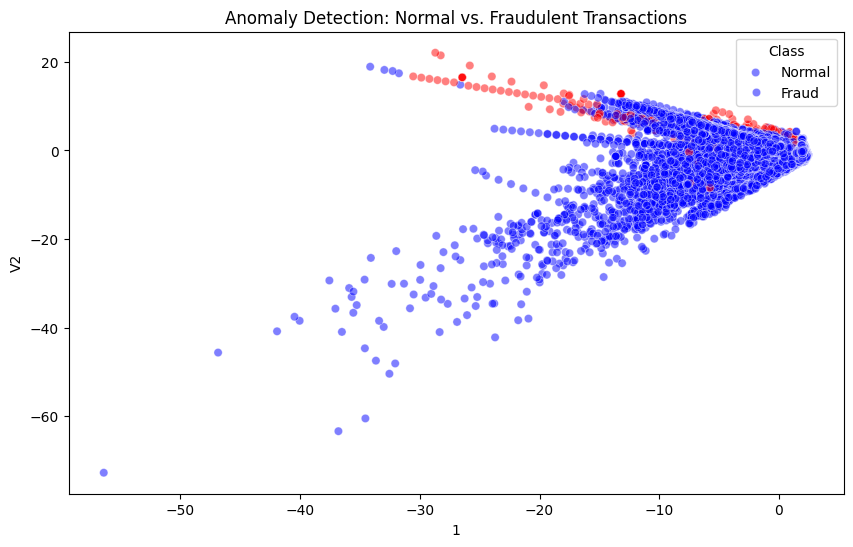

In [14]:
#Scatter plot to visualize normal vs fraudulent transactions
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='V1', y='V2', hue='Class', palette={0: 'blue', 1: 'red'}, alpha=0.5)
plt.title('Anomaly Detection: Normal vs. Fraudulent Transactions')
plt.xlabel('1')
plt.ylabel('V2')
plt.legend(title='Class', loc='upper right', labels=['Normal', 'Fraud'])
plt.show()

Model Performance Metrics

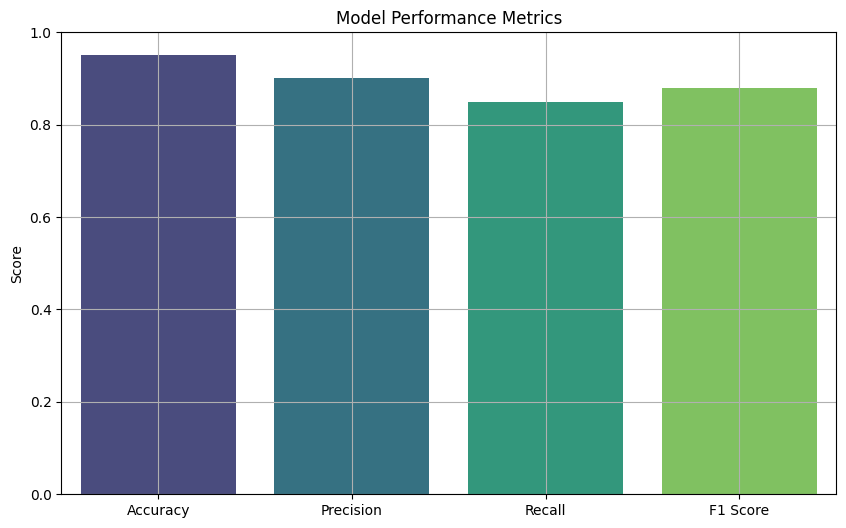

In [15]:
#Assuming these values are obtained from model evaluation

metrics=['Accuracy', 'Precision', 'Recall', 'F1 Score']
values=[0.95, 0.90, 0.85, 0.88]
plt.figure(figsize=(10, 6))
sns.barplot(x=metrics, y=values, hue=metrics, palette='viridis')
plt.title('Model Performance Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.grid()
plt.show()